# 04 · Selección del umbral τ
**Proyecto:** Salud en la esfera pública — análisis de tweets en español  
**Equivalente original:** `5_seleccion_umbral_ciencia.ipynb`

---

### ¿Qué hace este notebook?

Determina el umbral óptimo τ para decidir si un tweet contiene  
una mención efectiva de salud. El proceso tiene **dos fases**:

**FASE A — Preparación** *(correr primero)*
1. Filtra tweets con score ≥ 0.43
2. Muestra 10 tweets por subcategoría de forma balanceada
3. Exporta `seleccion_umbral.xlsx` para anotación manual
4. **→ Pausa: anotar la columna `valido_salud` (1 = sí es salud, 0 = no)**

**FASE B — Optimización** *(correr después de anotar)*
5. Lee el archivo anotado
6. Calcula accuracy para cada umbral posible
7. Selecciona τ óptimo y lo aplica al corpus completo
8. Guarda el corpus final etiquetado

### Diferencias con el paper

| Aspecto | Paper | Este notebook |
|---|---|---|
| Unidad | Chunk (`chunk_uid = id_doc + chunk_id`) | Tweet (`id_doc`) |
| Columna a anotar | `valido_ciencia` | `valido_salud` |
| Subcategorías | 17 (Tesauro Ciencia) | 12 (Tesauro Salud) |
| Muestra por subcategoría | 10 | 10 |

**Entradas:**
- `resultadosPropios/similitudes_tweets.parquet`

**Salidas:**
- `resultadosPropios/seleccion_umbral.xlsx` ← **anotar manualmente**
- `resultadosPropios/fig_scores_por_etiqueta.png`
- `resultadosPropios/fig_accuracy_umbral.png`
- `resultadosPropios/tweets_etiquetados_final.parquet` ← corpus definitivo
- `resultadosPropios/salud_tweets_final.parquet` ← solo tweets con salud


## 0 · Configuración

In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\OneDrive\Documentos\GitHub\icare\kMetodo\resultadosPropios')

# Nombres de las subcategorias (deben coincidir con el notebook 03)
SUBCAT_NOMBRES = [
    'Salud_Economia_salud',
    'Salud_Estadisticas_sanitarias',
    'Salud_Higiene',
    'Salud_Control_alimentos',
    'Salud_Epidemiologia',
    'Salud_Higiene_ambiental',
    'Salud_Lucha_enfermedades',
    'Salud_Politica_drogas',
    'Salud_Toxicomania',
    'Salud_Salud_mujer',
    'Salud_Materno_infantil',
    'Salud_Mental',
]

SCORE_MINIMO   = 0.43   # filtro previo al muestreo (igual que el paper)
MUESTRA_N      = 10     # tweets por subcategoria para validacion manual

print('[CONFIG] OK')
print(f'  DATA_PROCESSED   : {DATA_PROCESSED.resolve()}')
print(f'  Subcategorias    : {len(SUBCAT_NOMBRES)}')
print(f'  Score minimo     : {SCORE_MINIMO}')
print(f'  Muestra por cat  : {MUESTRA_N}')


[CONFIG] OK
  DATA_PROCESSED   : C:\Users\afpue\OneDrive\Documentos\GitHub\icare\kMetodo\resultadosPropios
  Subcategorias    : 12
  Score minimo     : 0.43
  Muestra por cat  : 10


---
## ─── FASE A: Preparación de la muestra para anotación manual ───


## 1 · Cargar similitudes

In [2]:
# ============================================================
# CELL 1 — CARGA
# Equivalente a: sim_df = pd.read_excel('similitudes_chunks.xlsx')
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sim_df = pd.read_parquet(DATA_PROCESSED / 'similitudes_tweets.parquet')

# Asegurar que las columnas de subcategorias son numericas
for col in SUBCAT_NOMBRES:
    sim_df[col] = pd.to_numeric(sim_df[col], errors='coerce')

print(f'Tweets cargados  : {len(sim_df):,}')
print(f'Columnas         : {list(sim_df.columns)}')
sim_df.head(3)


Tweets cargados  : 151,424
Columnas         : ['id_doc', 'autor', 'fecha', 'Salud_Economia_salud', 'Salud_Estadisticas_sanitarias', 'Salud_Higiene', 'Salud_Control_alimentos', 'Salud_Epidemiologia', 'Salud_Higiene_ambiental', 'Salud_Lucha_enfermedades', 'Salud_Politica_drogas', 'Salud_Toxicomania', 'Salud_Salud_mujer', 'Salud_Materno_infantil', 'Salud_Mental', 'score_max', 'subcat_max']


,id_doc,autor,fecha,Salud_Economia_salud,Salud_Estadisticas_sanitarias,Salud_Higiene,Salud_Control_alimentos,Salud_Epidemiologia,Salud_Higiene_ambiental,Salud_Lucha_enfermedades,Salud_Politica_drogas,Salud_Toxicomania,Salud_Salud_mujer,Salud_Materno_infantil,Salud_Mental,score_max,subcat_max
0,1,@treporta,2020-06-03,0.108315,0.207589,0.228836,0.148676,0.420019,0.175693,0.283072,0.078428,0.093693,0.158637,0.229696,0.011602,0.420019,Salud_Epidemiologia
1,2,@annytak21,2020-06-03,0.081781,0.245268,0.145530,0.026931,0.219293,0.101776,0.178353,0.073949,0.133602,0.249742,0.226577,0.128509,0.249742,Salud_Salud_mujer
2,3,@ferumapress,2020-06-03,0.194415,0.254547,0.134160,0.082347,0.219495,0.109057,0.162065,0.146850,0.159413,0.369606,0.306537,0.247940,0.369606,Salud_Salud_mujer


## 2 · Filtrar scores ≥ 0.43 y muestrear por subcategoría
Replica exacta de las celdas 4-8 del paper:  
para cada tweet tomamos la subcategoría con mayor score;  
si supera 0.43 entra al pool de candidatos.  
Luego se seleccionan 10 por subcategoría de forma balanceada.


In [3]:
# ============================================================
# CELL 2 — FILTRAR Y MUESTREAR
# Equivalente a celdas 4-8 del paper
# ============================================================

sim_temp = sim_df[SUBCAT_NOMBRES].astype(float)

# Para cada tweet: mejor subcategoria y su score
sim_df['score_max']  = sim_temp.max(axis=1)
sim_df['subcat_max'] = sim_temp.idxmax(axis=1)

# Filtrar los que superan el score minimo
sim_filtered = sim_df[sim_df['score_max'] >= SCORE_MINIMO][[
    'id_doc', 'autor', 'fecha',
    'subcat_max', 'score_max'
]].copy()
sim_filtered = sim_filtered.rename(columns={
    'subcat_max': 'categoria',
    'score_max' : 'score',
})

print(f'Tweets elegibles (score >= {SCORE_MINIMO}): {len(sim_filtered):,}')
print()
print('Por subcategoria:')
print(sim_filtered['categoria'].value_counts().to_string())


Tweets elegibles (score >= 0.43): 35,460

Por subcategoria:
categoria
Salud_Epidemiologia              21053
Salud_Lucha_enfermedades          5496
Salud_Estadisticas_sanitarias     3179
Salud_Higiene                     2424
Salud_Economia_salud              1025
Salud_Politica_drogas              540
Salud_Higiene_ambiental            444
Salud_Materno_infantil             440
Salud_Salud_mujer                  387
Salud_Control_alimentos            271
Salud_Mental                       108
Salud_Toxicomania                   93


In [4]:
# ============================================================
# Seleccion balanceada: hasta MUESTRA_N tweets por subcategoria
# Equivalente a celdas 6-8 del paper
# ============================================================

frames = []
for cat in SUBCAT_NOMBRES:
    candidatos = sim_filtered[sim_filtered['categoria'] == cat]
    if len(candidatos) == 0:
        print(f'  [AVISO] Sin candidatos para: {cat}')
        continue
    muestra = candidatos.sample(
        min(len(candidatos), MUESTRA_N), random_state=42
    )
    frames.append(muestra)

final_selection = pd.concat(frames, ignore_index=True)
final_selection = final_selection.drop_duplicates(subset=['id_doc'])

# Recuperar el texto del tweet para facilitar la anotacion
corpus = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
final_selection = final_selection.merge(
    corpus[['id_doc', 'Texto_limpio']],
    on='id_doc', how='left'
)

# Columna vacia para anotar manualmente
final_selection['valido_salud'] = ''

print(f'Muestra total para anotacion: {len(final_selection)} tweets')
final_selection.head()


Muestra total para anotacion: 120 tweets


,id_doc,autor,fecha,categoria,score,Texto_limpio,valido_salud
0,84363,@dmoyaec,2020-04-12,Salud_Economia_salud,0.473245,Mientras que el estado se encarga trata de reg...,
1,57819,@emeequis,2020-06-01,Salud_Economia_salud,0.430152,El Covid19 puso sobre la palestra la terrible ...,
2,72451,@csregionmurcia,2020-07-08,Salud_Economia_salud,0.459223,Cs apuesta por mejorar la economa social. Modi...,
3,4642,@pacomolinasss,2020-06-11,Salud_Economia_salud,0.452361,"para las derechas, tanto tienes tanto vales.Lo...",
4,94902,@diariomedico,2020-04-16,Salud_Economia_salud,0.440553,COVID19 denuncia que cesan a decenas de enferm...,


## 3 · Exportar para anotación manual

In [5]:
# ============================================================
# CELL 3 — EXPORTAR
# Equivalente a: final_selection.to_excel('seleccion_umbral.xlsx')
# ============================================================

ruta_salida = DATA_PROCESSED / 'seleccion_umbral.xlsx'
final_selection.to_excel(ruta_salida, index=False, engine='openpyxl')

print(f'[GUARDADO] {ruta_salida}')
print()
print('*** ACCION REQUERIDA ***')
print('1. Abre el archivo seleccion_umbral.xlsx')
print('2. Lee cada tweet en la columna Texto_limpio')
print('3. Rellena la columna valido_salud:')
print('      1 = el tweet habla de salud (segun la categoria asignada)')
print('      0 = el tweet NO habla de salud')
print('4. Guarda el archivo como seleccion_umbral_anotado.xlsx')
print('5. Vuelve a correr desde la FASE B')


[GUARDADO] C:\Users\afpue\OneDrive\Documentos\GitHub\icare\kMetodo\resultadosPropios\seleccion_umbral.xlsx

*** ACCION REQUERIDA ***
1. Abre el archivo seleccion_umbral.xlsx
2. Lee cada tweet en la columna Texto_limpio
3. Rellena la columna valido_salud:
      1 = el tweet habla de salud (segun la categoria asignada)
      0 = el tweet NO habla de salud
4. Guarda el archivo como seleccion_umbral_anotado.xlsx
5. Vuelve a correr desde la FASE B


---
## ─── FASE B: Optimización del umbral *(correr tras anotar)* ───


## 4 · Leer archivo anotado

In [7]:
# ============================================================
# CELL 4 — LEER ARCHIVO ANOTADO
# Equivalente a: df_etiquetado = pd.read_excel('seleccion_umbral_etiquetado.xlsx')
# ============================================================

ruta_anotado = DATA_PROCESSED / 'seleccion_umbral_anotado.xlsx'

df_etiquetado = pd.read_excel(ruta_anotado, engine='openpyxl')

# Asegurar que la columna es numerica
df_etiquetado['valido_salud'] = pd.to_numeric(
    df_etiquetado['valido_salud'], errors='coerce'
)

n_anotados = df_etiquetado['valido_salud'].notna().sum()
print(f'Tweets anotados   : {n_anotados}')
print(f'Valores unicos    : {df_etiquetado["valido_salud"].unique()}')
print(f'Positivos (salud) : {int(df_etiquetado["valido_salud"].sum())}')
print(f'Negativos         : {int((df_etiquetado["valido_salud"]==0).sum())}')
df_etiquetado.head(3)


Tweets anotados   : 120
Valores unicos    : [1 0]
Positivos (salud) : 109
Negativos         : 11


,id_doc,autor,fecha,categoria,score,Texto_limpio,valido_salud
0,84363,@dmoyaec,2020-04-12,Salud_Economia_salud,0.473245,Mientras que el estado se encarga trata de reg...,1
1,57819,@emeequis,2020-06-01,Salud_Economia_salud,0.430152,El Covid19 puso sobre la palestra la terrible ...,1
2,72451,@csregionmurcia,2020-07-08,Salud_Economia_salud,0.459223,Cs apuesta por mejorar la economa social. Modi...,0


## 5 · Distribución de scores por etiqueta
Equivalente a la celda 17 del paper — permite ver visualmente  
si los tweets anotados como salud tienen scores más altos.


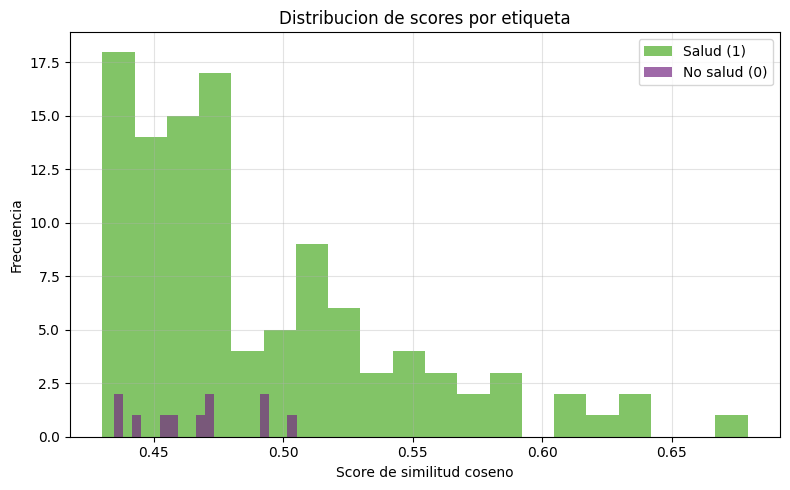

[GUARDADO] fig_scores_por_etiqueta.png


In [8]:
# ============================================================
# CELL 5 — DISTRIBUCION DE SCORES POR ETIQUETA
# Equivalente a celdas 17-18 del paper
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df_etiquetado[df_etiquetado['valido_salud'] == 1]['score'],
    bins=20, alpha=0.7, label='Salud (1)', color='#4dac26'
)
ax.hist(
    df_etiquetado[df_etiquetado['valido_salud'] == 0]['score'],
    bins=20, alpha=0.7, label='No salud (0)', color='#762a83'
)
ax.grid(True, alpha=0.35)
ax.set_xlabel('Score de similitud coseno')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion de scores por etiqueta')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_scores_por_etiqueta.png', dpi=300)
plt.show()
print('[GUARDADO] fig_scores_por_etiqueta.png')


## 6 · Encontrar el umbral óptimo τ
Barremos todos los valores posibles de τ entre 0 y 1  
y calculamos la accuracy contra las etiquetas manuales.  
El τ que maximiza la accuracy es el umbral óptimo.


In [13]:
# ============================================================
# CELL 6 — UMBRAL POR PUNTO DE INFLEXIÓN DE LA CURVA
# Busca donde la curva de accuracy cae más rápido,
# es decir, donde la segunda derivada es mínima.
# ============================================================

umbrales   = np.linspace(0, 1, 1001)
resultados = []

y_true = df_etiquetado['valido_salud'].dropna().astype(int)
scores = df_etiquetado.loc[y_true.index, 'score']

for u in umbrales:
    pred = (scores >= u).astype(int)
    acc  = (pred == y_true).mean()
    resultados.append((u, acc))

thresholds = np.array([r[0] for r in resultados])
accuracies = np.array([r[1] for r in resultados])

# Segunda derivada — el mínimo marca el punto de inflexión
segunda_deriv = np.gradient(np.gradient(accuracies, thresholds), thresholds)

# Solo buscamos en la zona donde la curva está cayendo (acc < max)
# para evitar que coja el τ=0
zona_caida = thresholds >= 0.35   # ignoramos el plateau inicial
idx_inflexion = np.argmin(segunda_deriv[zona_caida])
mejor_umbral  = thresholds[zona_caida][idx_inflexion]
mejor_acc     = accuracies[zona_caida][idx_inflexion]

print(f'Punto de inflexion : tau = {mejor_umbral:.3f}')
print(f'Accuracy en ese punto : {mejor_acc:.3f}')

Punto de inflexion : tau = 0.435
Accuracy en ese punto : 0.892


## 7 · Gráfica: accuracy como función del umbral
Réplica exacta de las celdas 23-24 del paper (mismos colores y estilo).


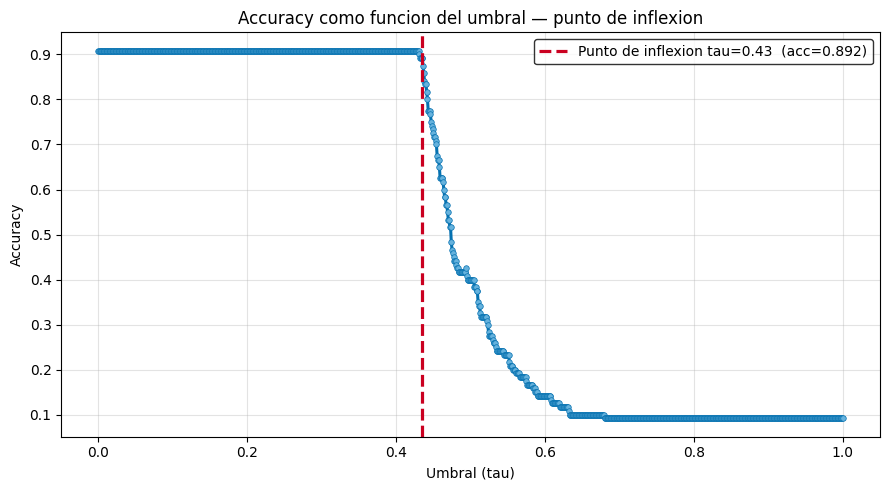

[GUARDADO] fig_accuracy_umbral.png


In [14]:
# ============================================================
# CELL 7 — GRAFICA CON PUNTO DE INFLEXIÓN MARCADO
# ============================================================

color_line      = '#0571b0'
color_threshold = '#ca0020'
color_fill      = '#66b2dd'

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    thresholds, accuracies,
    marker='o', linewidth=2.2, markersize=4,
    color=color_line,
    markerfacecolor=color_fill,
    markeredgecolor=color_line,
    markeredgewidth=0.5,
)
ax.axvline(
    mejor_umbral,
    color=color_threshold, linestyle='--', linewidth=2.3,
    label=f'Punto de inflexion tau={mejor_umbral:.2f}  (acc={mejor_acc:.3f})'
)
ax.set_xlabel('Umbral (tau)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy como funcion del umbral — punto de inflexion')
ax.grid(True, alpha=0.35)
ax.legend(frameon=True, facecolor='white', edgecolor='black')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_accuracy_umbral.png', dpi=300)
plt.show()
print(f'[GUARDADO] fig_accuracy_umbral.png')

## 8 · Aplicar umbral óptimo al corpus completo
Con el τ óptimo calibrado, re-etiquetamos todos los tweets  
y guardamos el corpus definitivo.


In [15]:
# ============================================================
# CELL 8 — APLICAR UMBRAL AL CORPUS COMPLETO
# Equivalente a las celdas de guardado 23-24 del paper
# ============================================================

TAU = mejor_umbral

# Re-leer similitudes y reetiquetas con tau optimo
sim_df = pd.read_parquet(DATA_PROCESSED / 'similitudes_tweets.parquet')
for col in SUBCAT_NOMBRES:
    sim_df[col] = pd.to_numeric(sim_df[col], errors='coerce')

sim_temp              = sim_df[SUBCAT_NOMBRES].astype(float)
sim_df['score_max']   = sim_temp.max(axis=1)
sim_df['subcat_max']  = sim_temp.idxmax(axis=1)
sim_df['etiqueta_salud'] = (sim_df['score_max'] >= TAU).astype(int)
sim_df['categoria_detectada'] = sim_df.apply(
    lambda r: r['subcat_max'] if r['etiqueta_salud'] == 1 else 'ninguna',
    axis=1
)

n_salud = sim_df['etiqueta_salud'].sum()
pct     = n_salud / len(sim_df) * 100
print(f'Umbral optimo tau = {TAU:.3f}')
print(f'Tweets con salud  : {n_salud:,} ({pct:.1f}%)')
print()
print('Distribucion por subcategoria:')
print(
    sim_df[sim_df['etiqueta_salud']==1]['categoria_detectada']
    .value_counts().to_string()
)


Umbral optimo tau = 0.435
Tweets con salud  : 33,982 (22.4%)

Distribucion por subcategoria:
categoria_detectada
Salud_Epidemiologia              20409
Salud_Lucha_enfermedades          5234
Salud_Estadisticas_sanitarias     2959
Salud_Higiene                     2323
Salud_Economia_salud               944
Salud_Politica_drogas              499
Salud_Higiene_ambiental            415
Salud_Materno_infantil             410
Salud_Salud_mujer                  357
Salud_Control_alimentos            244
Salud_Mental                       101
Salud_Toxicomania                   87


## 9 · Guardar corpus etiquetado definitivo

In [16]:
# ============================================================
# CELL 9 — GUARDAR
# Equivalente a:
#   resultado.to_excel('chunks_etiquetados_binario.xlsx')
#   resultado_ciencia.to_excel('ciencia_chunks.xlsx')
# ============================================================

# Corpus completo etiquetado
sim_df.to_parquet(
    DATA_PROCESSED / 'tweets_etiquetados_final.parquet', index=False
)
print('[GUARDADO] tweets_etiquetados_final.parquet')

# Solo tweets con mencion de salud
salud_final = sim_df[sim_df['etiqueta_salud'] == 1].copy()
salud_final.to_parquet(
    DATA_PROCESSED / 'salud_tweets_final.parquet', index=False
)
print('[GUARDADO] salud_tweets_final.parquet')

# Excel para inspeccion
salud_final.to_excel(
    DATA_PROCESSED / 'salud_tweets_final.xlsx', index=False, engine='openpyxl'
)
print('[GUARDADO] salud_tweets_final.xlsx')

print()
print(f'  Total tweets         : {len(sim_df):,}')
print(f'  Tweets con salud     : {len(salud_final):,} ({len(salud_final)/len(sim_df)*100:.1f}%)')
print(f'  Umbral tau optimo    : {TAU:.3f}')
print(f'  Accuracy validacion  : {mejor_acc:.3f}')
print()
print('Notebook 04 completado.')
print('Siguiente -> 05_descriptivos_salud.ipynb')


[GUARDADO] tweets_etiquetados_final.parquet
[GUARDADO] salud_tweets_final.parquet
[GUARDADO] salud_tweets_final.xlsx

  Total tweets         : 151,424
  Tweets con salud     : 33,982 (22.4%)
  Umbral tau optimo    : 0.435
  Accuracy validacion  : 0.892

Notebook 04 completado.
Siguiente -> 05_descriptivos_salud.ipynb
